# 01. Khám phá Môi trường Tetris (Environment Exploration)

Notebook này dùng để kiểm tra logic của `TetrisEnv`, cách nó phản hồi với các hành động ngẫu nhiên và các chỉ số Heuristic (Holes, Bumpiness, Height).

In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Thêm folder backend vào path để import được các module
ROOT_DIR = Path(os.getcwd()).parent
sys.path.append(str(ROOT_DIR / "backend"))

from env.tetris_env import TetrisEnv

## 1. Khởi tạo Môi trường

In [2]:
env = TetrisEnv(render_mode=None)
state, info = env.reset()

print("Trạng thái ban đầu (Features):", state)
print("Thông tin chi tiết (Heuristics):", info)
print("Kích thước bàn cờ:", env.engine.width, "x", env.engine.height)

Trạng thái ban đầu (Features): [0, 0, 0, 0]
Thông tin chi tiết (Heuristics): {'holes': 0, 'bumpiness': 0, 'height': 0}
Kích thước bàn cờ: 10 x 20


## 2. Kiểm tra các trạng thái có thể đi tiếp (Possible Next States)

Trong Tetris DRL này, thay vì chọn từng phím qua trái/phải, Agent sẽ nhìn vào tất cả các vị trí có thể thả khối gạch hiện tại và chọn vị trí tốt nhất.

In [3]:
next_states = env.get_possible_states()
print(f"Có {len(next_states)} vị trí có thể thả khối gạch hiện tại.")

# Hiển thị thử một vài action mẫu: (Cột, Số lần xoay)
sample_actions = list(next_states.keys())[:5]
for action in sample_actions:
    print(f"Action {action}: Features tương ứng -> {next_states[action]}")

Có 34 vị trí có thể thả khối gạch hiện tại.
Action (0, 0): Features tương ứng -> [np.int64(0), np.int64(0), 3, 4]
Action (1, 0): Features tương ứng -> [np.int64(0), np.int64(0), 4, 4]
Action (2, 0): Features tương ứng -> [np.int64(0), np.int64(0), 4, 4]
Action (3, 0): Features tương ứng -> [np.int64(0), np.int64(0), 4, 4]
Action (4, 0): Features tương ứng -> [np.int64(0), np.int64(0), 4, 4]


## 3. Chạy thử một ván chơi ngẫu nhiên (Random Walk)

Chúng ta sẽ cho một Agent ngẫu nhiên chơi và thu thập dữ liệu về Reward.

In [4]:
env.reset()
total_reward = 0
steps = 0
rewards = []
done = False

print("Bắt đầu chơi ngẫu nhiên...")
while not done and steps < 1000:
    next_states = env.get_possible_states()
    if not next_states:
        break
        
    # Chọn ngẫu nhiên 1 action trong các action hợp lệ
    actions = list(next_states.keys())
    random_action = actions[np.random.choice(len(actions))]
    
    state, reward, done, _, info = env.step(random_action)
    
    total_reward += reward
    rewards.append(reward)
    steps += 1

print(f"Kết thúc ván đấu sau {steps} bước.")
print(f"Tổng Reward nhận được: {total_reward:.2f}")
print(f"Trạng thái cuối cùng của bàn cờ: {info}")

Bắt đầu chơi ngẫu nhiên...
Kết thúc ván đấu sau 15 bước.
Tổng Reward nhận được: 13.00
Trạng thái cuối cùng của bàn cờ: {'holes': np.int64(78), 'bumpiness': 24, 'height': 138}


## 4. Trực quan hóa phần thưởng (Reward Visualization)

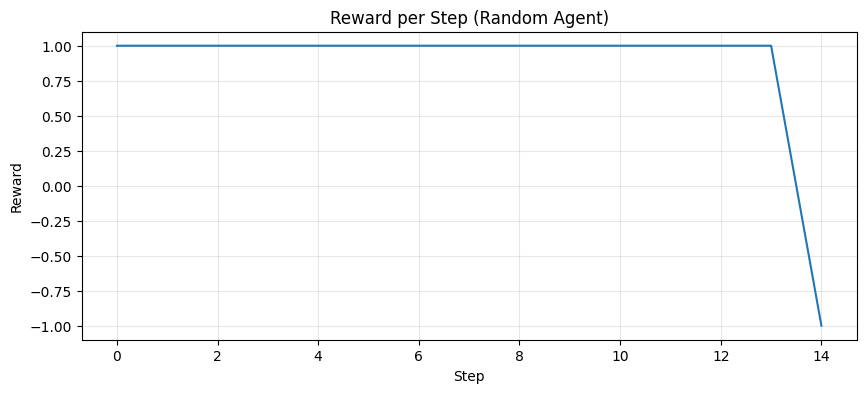

In [5]:
plt.figure(figsize=(10, 4))
plt.plot(rewards)
plt.title("Reward per Step (Random Agent)")
plt.xlabel("Step")
plt.ylabel("Reward")
plt.grid(True, alpha=0.3)
plt.show()